In [112]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import h5py
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

In [113]:
# Load Exp Data
def load_ExpData(file_, idx_str_):
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:
        # Data
        return dict(
            freq_comb=np.asarray(dataset[idx_str_]["freq_comb"]),
            freq_pumps = dataset[idx_str_]["freq_pumps"],
            df=np.asarray(dataset[idx_str_]["df"]),
            USB=np.asarray(dataset[idx_str_]["USB"]),
            DC_Bias=np.asarray(dataset[idx_str_]["DC_Bias"]),
            Pump_Amps=np.asarray(dataset[idx_str_]["pump_pwr_sweep"])
            )

In [114]:
from json import load


folder = "/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/JPA Measurements/I:/JPA-Data/2026-02/Resonance"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

# Pick the most recently modified one
file = max(files, key=os.path.getmtime)

print("Selected file:", file)

# Extract the run name automatically
run = os.path.basename(file).replace(".hdf5", "")
print("Run:", run)

resonance = load_ExpData(
    file_ = file,
    idx_str_= run
    )['USB']
resonance=np.array(resonance)

freqs = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_comb']

df = load_ExpData(
    file_ = file,
    idx_str_= run
    )['df'] / 1e6

DC_Bias = load_ExpData(
    file_ = file,
    idx_str_= run
    )['DC_Bias']

pump_Amps = load_ExpData(
    file_ = file,
    idx_str_= run
    )['Pump_Amps']

freq_pumps = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_pumps']

print(freq_pumps)

Selected file: /home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/JPA Measurements/I:/JPA-Data/2026-02/Resonance/2026-02-23_11_26_32.hdf5
Run: 2026-02-23_11_26_32
<Closed HDF5 dataset>


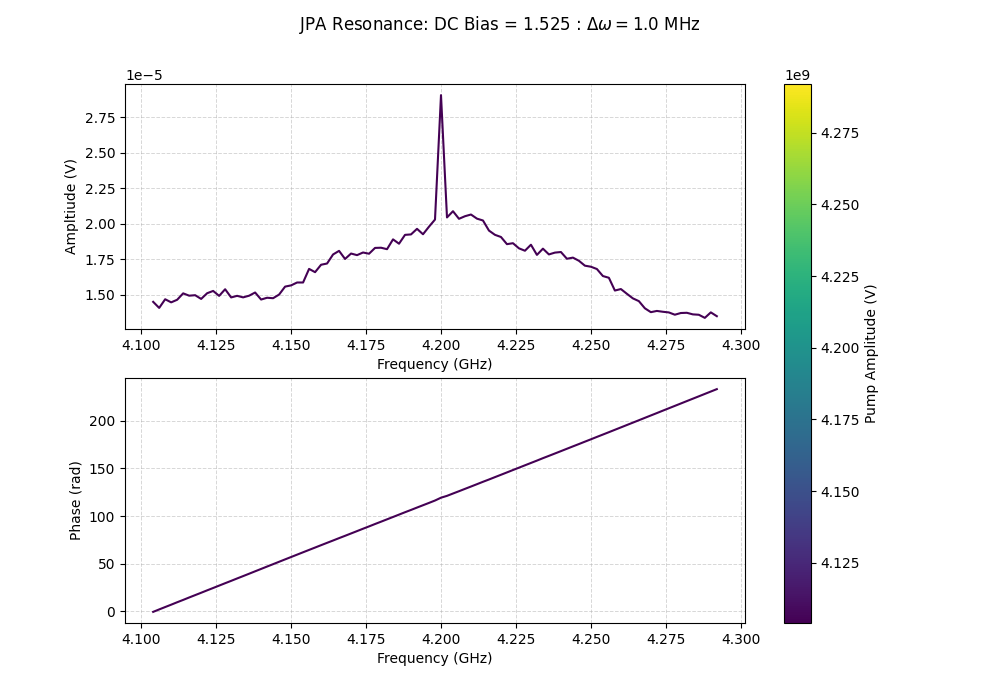

In [115]:
fig, ax = plt.subplots(nrows= 2, figsize=(10, 7))

# Colormap and normalization
cmap = cm.viridis
norm = mcolors.Normalize(vmin=freqs[0], vmax=freqs[-1])

# Data

colors = cmap(norm(pump_Amps))
ax[0].plot(
    freqs/1e9, 
    np.abs(resonance), 
    label= '$A_{sig} = $ ' + str(np.round(pump_Amps, 2)) + 'V',
    color = colors
    )
ax[1].plot(
    freqs/1e9, 
    np.unwrap(np.angle(resonance)), 
    label= '$pump_{sig} = $ ' + str(np.round(pump_Amps, 2)) + 'V',
    color = colors
    )

# Grid and labels
ax[0].grid(ls='--', lw=0.7, alpha=0.5)
ax[1].grid(ls='--', lw=0.7, alpha=0.5)
ax[0].set_xlabel('Frequency (GHz)')
ax[0].set_ylabel('Ampltiude (V)')
ax[1].set_xlabel('Frequency (GHz)')
ax[1].set_ylabel('Phase (rad)')

# plot limits
#ax[0].set_xlim(freq_centre/1e9, np.max(freqs)/1e9)
#ax[1].set_xlim(freq_centre/1e9, np.max(freqs)/1e9)


# --- ADD COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])   # required for older matplotlib versions
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Pump Amplitude (V)")



fig.suptitle(
    f'JPA Resonance: DC Bias = {DC_Bias} : $\\Delta \\omega = ${df} MHz'
    ) 
# Save plot
#fig.savefig(f"Figures/LKIPA_Res_{df}_DCB_4_sig_0.3.png", dpi=300, bbox_inches="tight")
plt.show()